<a href="https://colab.research.google.com/github/nadiaabdelsamea/car-prices/blob/main/car_pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/alexeygrigorev/mlbookcamp-code

Cloning into 'mlbookcamp-code'...
remote: Enumerating objects: 4489, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 4489 (delta 45), reused 33 (delta 33), pack-reused 4434 (from 1)
Receiving objects: 100% (4489/4489), 9.03 MiB | 11.71 MiB/s, done.
Resolving deltas: 100% (2720/2720), done.


In [ ]:
import pandas as pd
df=pd.read_csv("/content/mlbookcamp-code/chapter-02-car-price/data.csv")

In [ ]:
df.shape

(11914, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [ ]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
df['Vehicle Style'].value_counts()

,count
Vehicle Style,
Sedan,3048
4dr SUV,2488
Coupe,1211
Convertible,793
4dr Hatchback,702
Crew Cab Pickup,681
Extended Cab Pickup,623
Wagon,592
2dr Hatchback,506


In [ ]:
df=df.drop(columns={"Market Category","Model"})

In [ ]:
df.head()

,Make,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


In [ ]:
df.columns=df.columns.str.lower().str.replace(" ","_")

In [ ]:
df.head()

,make,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


In [ ]:
df=df.rename(columns={"msrp":"price"})

In [ ]:
df['price'].value_counts()

,count
price,
2000,1036
29995,19
25995,19
27995,16
20995,16
...,...
26115,1
27705,1
26610,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='price', ylabel='Count'>

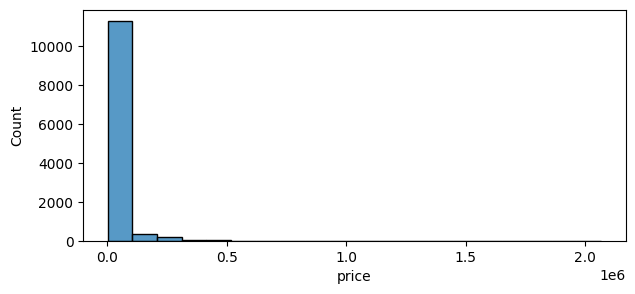

In [ ]:
plt.figure(figsize=(7,3))
sns.histplot(df['price'],bins=20)

In [ ]:
import numpy as np
df['price']=np.log1p(df.price)

In [ ]:
df['price'].value_counts()

,count
price,
7.601402,1036
10.308819,19
10.165698,19
10.239817,16
9.952087,16
...,...
10.170303,1
10.229404,1
10.189080,1


<Axes: xlabel='price', ylabel='Count'>

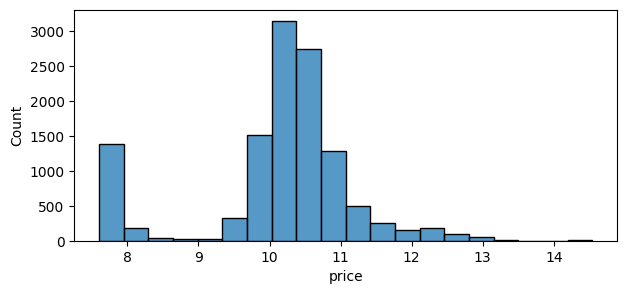

In [ ]:
plt.figure(figsize=(7,3))
sns.histplot(df['price'],bins=20)

In [ ]:
df.isnull().sum()

,0
make,0
year,0
engine_fuel_type,3
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
vehicle_size,0
vehicle_style,0


In [ ]:
df['engine_fuel_type']=df['engine_fuel_type'].fillna(df['engine_fuel_type'].mode()[0])

In [ ]:
df.isnull().sum()

,0
make,0
year,0
engine_fuel_type,0
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
vehicle_size,0
vehicle_style,0


In [ ]:
df['engine_hp']=df['engine_hp'].fillna(df['engine_hp'].mean())

In [ ]:
df['engine_cylinders']=df['engine_cylinders'].fillna(df['engine_cylinders'].mean())

In [ ]:
df['number_of_doors']=df['number_of_doors'].fillna(df['number_of_doors'].mean())

In [ ]:
df.isnull().sum()

,0
make,0
year,0
engine_fuel_type,0
engine_hp,0
engine_cylinders,0
transmission_type,0
driven_wheels,0
number_of_doors,0
vehicle_size,0
vehicle_style,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  object 
 1   year               11914 non-null  int64  
 2   engine_fuel_type   11914 non-null  object 
 3   engine_hp          11914 non-null  float64
 4   engine_cylinders   11914 non-null  float64
 5   transmission_type  11914 non-null  object 
 6   driven_wheels      11914 non-null  object 
 7   number_of_doors    11914 non-null  float64
 8   vehicle_size       11914 non-null  object 
 9   vehicle_style      11914 non-null  object 
 10  highway_mpg        11914 non-null  int64  
 11  city_mpg           11914 non-null  int64  
 12  popularity         11914 non-null  int64  
 13  price              11914 non-null  float64
dtypes: float64(4), int64(4), object(6)
memory usage: 1.3+ MB


In [ ]:
df['engine_fuel_type'].value_counts()

,count
engine_fuel_type,
regular unleaded,7175
premium unleaded (required),2009
premium unleaded (recommended),1523
flex-fuel (unleaded/E85),899
diesel,154
electric,66
flex-fuel (premium unleaded required/E85),54
flex-fuel (premium unleaded recommended/E85),26
flex-fuel (unleaded/natural gas),6


In [ ]:
df=pd.get_dummies(df,columns=['vehicle_style','vehicle_size','driven_wheels','transmission_type',
                              'engine_fuel_type','make'])

In [ ]:
df.head()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,price,vehicle_style_2dr Hatchback,vehicle_style_2dr SUV,...,make_Rolls-Royce,make_Saab,make_Scion,make_Spyker,make_Subaru,make_Suzuki,make_Tesla,make_Toyota,make_Volkswagen,make_Volvo
0,2011,335.0,6.0,2.0,26,19,3916,10.739349,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2011,300.0,6.0,2.0,28,19,3916,10.612779,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2011,300.0,6.0,2.0,28,20,3916,10.500977,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2011,230.0,6.0,2.0,28,18,3916,10.290483,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2011,230.0,6.0,2.0,28,18,3916,10.448744,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
x=df.drop(['price'], axis=1)
y=df['price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test ,y_train , y_test =train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
results=model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,results)

0.8634005554724169

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,results)
print(np.sqrt(mse))

0.41560791528403046


In [ ]:
from sklearn.tree import DecisionTreeRegressor
model2=DecisionTreeRegressor()
model2.fit(x_train,y_train)
result2=model2.predict(x_test)
print(r2_score(y_test,result2))
mse2=mean_squared_error(y_test,result2)
np.sqrt(mse2)

0.9901307528141844


np.float64(0.11171239344896727)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model3=RandomForestRegressor()
model3.fit(x_train,y_train)
result3=model3.predict(x_test)
print(r2_score(y_test,result3))
mse3=mean_squared_error(y_test,result3)
print(np.sqrt(mse3))

0.9918833482663891
0.10130894654240885


In [ ]:
result4=model3.predict(x_train)
print(r2_score(y_train,result4))

0.9967533345955019


In [ ]:
r=model2.predict(x_train)
print(r2_score(y_train,r))

0.9973170595894372


overfit & underfit